In [1]:
"""Simple node objects backed by the shared orbital network model."""

from pathlib import Path
import sys

repo_root = next(
    parent for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "mpex").is_dir()
)
network_python = repo_root / "network" / "python"
for path in (repo_root, network_python):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from network_graph import RELAYS, RELAY_PERIOD, SETTLEMENTS, System

try:
    from relay_placement import BRIEF_ANGLES
except (ImportError, ModuleNotFoundError):
    BRIEF_ANGLES = (45.0, 135.0)

from mpex.constants import NODE_IDS


class Node:
    """A named network node whose position is evaluated at a given time."""

    def __init__(self, name, system=None):
        if name not in NODE_IDS:
            raise ValueError(f"unknown node {name!r}")
        self.name = name
        self.node_id = NODE_IDS[name]
        self.system = system or System()

    def position(self, t_days=0.0):
        """Return the node's ``(x, y, z)`` position in AU."""
        return self.system.position(self.name, t_days)


class sender(Node):
    """A settlement node that can originate a transmission."""


class exchange(Node):
    """A settlement node representing a local exchange."""


class relay(Node):
    """A relay node in the backbone network."""


def create_nodes(system=None, t_days=0.0):
    """Create the settlement and relay nodes with their current positions.

    ``BRIEF_ANGLES`` is kept on the returned relay nodes as the placement
    reference used by the relay-placement study; actual coordinates come from
    ``network_graph.System`` so both models use the same orbital data.
    """
    system = system or System()
    nodes = {}
    for name in SETTLEMENTS:
        nodes[name] = sender(name, system)
        nodes[f"{name} exchange"] = exchange(name, system)
    for name, phase in zip(RELAYS, BRIEF_ANGLES):
        node = relay(name, system)
        node.placement_angle_deg = phase
        nodes[name] = node
    for node in nodes.values():
        node.current_position = node.position(t_days)
    return nodes

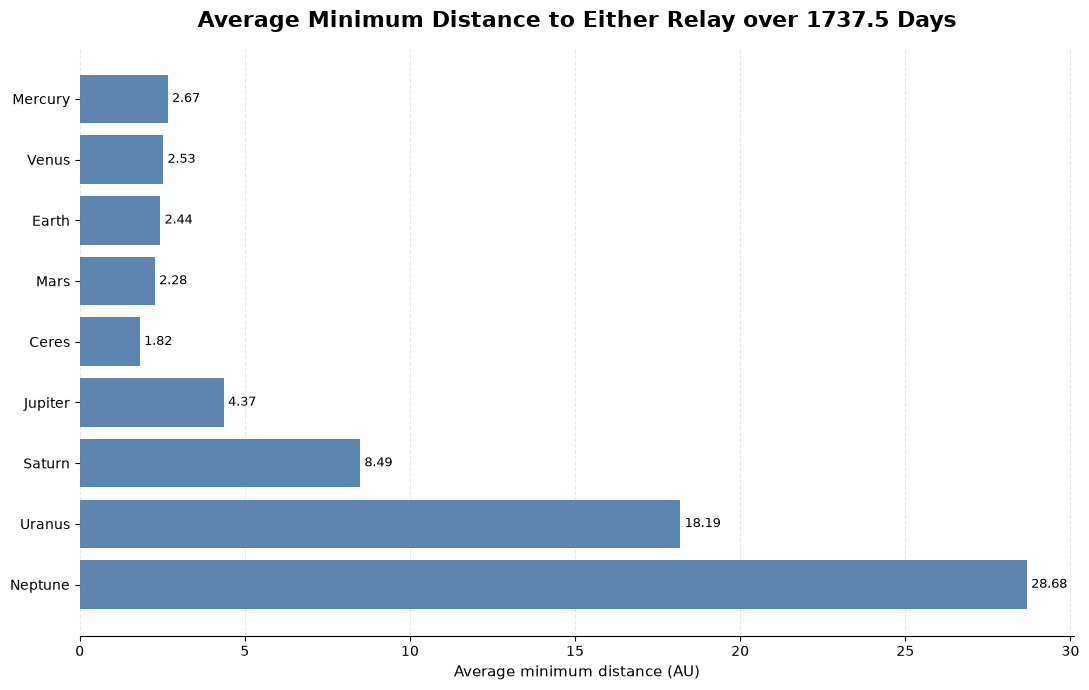

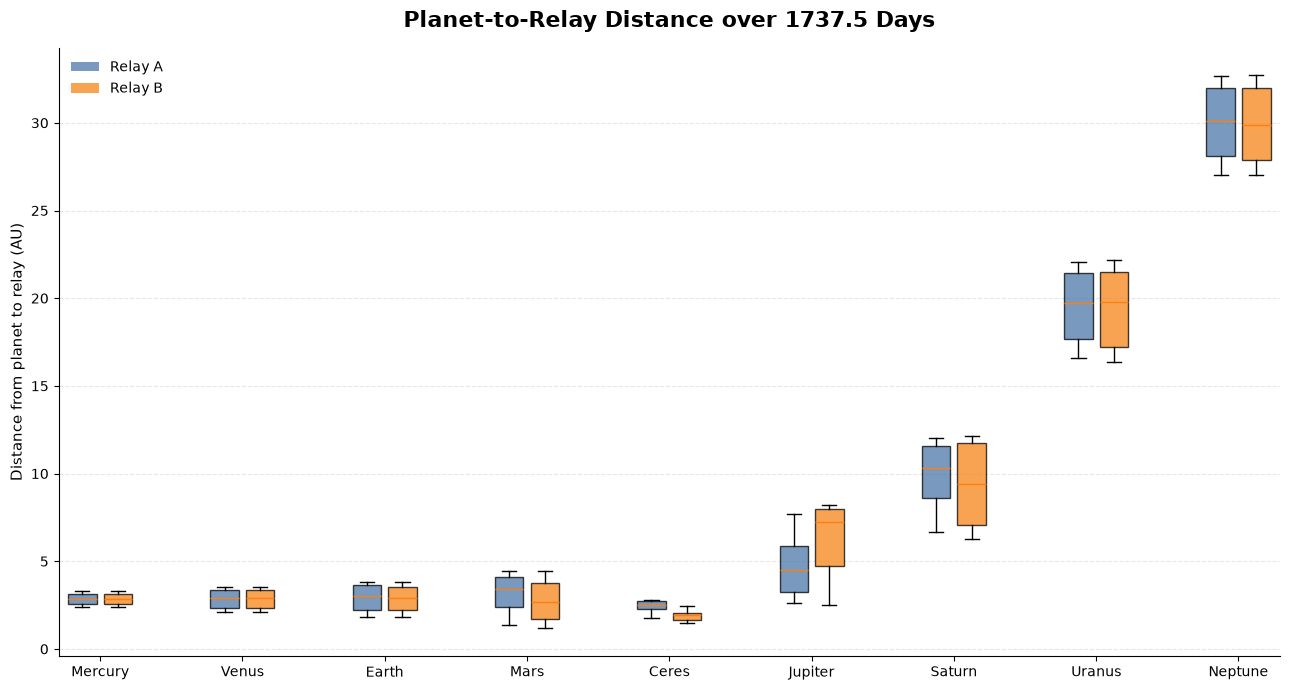

In [12]:
import numpy as np

import matplotlib.pyplot as plt

nodes = create_nodes()
sample_count = 4096
times_days = np.linspace(0.0, RELAY_PERIOD, sample_count, endpoint=False)
planet_positions = np.asarray([
    [nodes[planet].position(t_days) for planet in SETTLEMENTS]
    for t_days in times_days
])
relay_positions = np.asarray([
    [nodes[relay].position(t_days) for relay in RELAYS]
    for t_days in times_days
])

distance_by_relay = np.linalg.norm(
    planet_positions[:, :, np.newaxis, :] - relay_positions[:, np.newaxis, :, :],
    axis=-1,
)
minimum_distances = distance_by_relay.min(axis=2)
average_minimum_distance = minimum_distances.mean(axis=0)

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(
    SETTLEMENTS,
    average_minimum_distance,
    color="#4C78A8",
    alpha=0.9,
)
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel("Average minimum distance (AU)", fontsize=11)
ax.set_title(
    f"Average Minimum Distance to Either Relay over {RELAY_PERIOD:.1f} Days",
    fontsize=16,
    weight="bold",
    pad=15,
)
ax.grid(axis="x", linestyle="--", alpha=0.3)
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(13, 7))
box_data = []
box_positions = []
box_colors = []
planet_positions_on_axis = []
for planet_index, planet in enumerate(SETTLEMENTS):
    center = planet_index * 3 + 1.5
    planet_positions_on_axis.append(center)
    for relay_index in range(len(RELAYS)):
        box_data.append(distance_by_relay[:, planet_index, relay_index])
        box_positions.append(center + (relay_index - 0.5) * 0.75)
        box_colors.append(["#4C78A8", "#F58518"][relay_index])

boxplot = ax.boxplot(
    box_data,
    positions=box_positions,
    widths=0.6,
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(boxplot["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xticks(planet_positions_on_axis)
ax.set_xticklabels(SETTLEMENTS)
ax.set_ylabel("Distance from planet to relay (AU)", fontsize=11)
ax.set_title(
    f"Planet-to-Relay Distance over {RELAY_PERIOD:.1f} Days",
    fontsize=16,
    weight="bold",
    pad=15,
)
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor="#4C78A8", alpha=0.75, label="Relay A"),
    plt.Rectangle((0, 0), 1, 1, facecolor="#F58518", alpha=0.75, label="Relay B"),
]
ax.legend(handles=legend_handles, frameon=False)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

In [13]:
import pandas as pd

boxplot_rows = []
for planet_index, planet in enumerate(SETTLEMENTS):
    for relay_index, relay_name in enumerate(RELAYS):
        distances = distance_by_relay[:, planet_index, relay_index]
        boxplot_rows.append({
            "planet": planet,
            "reference": relay_name,
            "minimum_au": np.min(distances),
            "q1_au": np.percentile(distances, 25),
            "median_au": np.median(distances),
            "mean_au": np.mean(distances),
            "q3_au": np.percentile(distances, 75),
            "maximum_au": np.max(distances),
        })

boxplot_dataframe = pd.DataFrame(boxplot_rows)
print(boxplot_dataframe.to_string(index=False, float_format="{:.4f}".format))
boxplot_dataframe

 planet reference  minimum_au   q1_au  median_au  mean_au   q3_au  maximum_au
Mercury   Relay A      2.3641  2.5720     2.8489   2.8390  3.1047      3.2938
Mercury   Relay B      2.3638  2.5730     2.8607   2.8447  3.1124      3.2933
  Venus   Relay A      2.1016  2.3551     2.8978   2.8640  3.3769      3.5559
  Venus   Relay B      2.1016  2.3556     2.8780   2.8526  3.3511      3.5555
  Earth   Relay A      1.8153  2.1951     3.0038   2.9155  3.6315      3.8450
  Earth   Relay B      1.8127  2.1967     2.9119   2.8643  3.5216      3.8378
   Mars   Relay A      1.3677  2.4183     3.4267   3.2223  4.1108      4.4513
   Mars   Relay B      1.1769  1.7145     2.6920   2.7672  3.7851      4.4586
  Ceres   Relay A      1.7510  2.2752     2.4788   2.4463  2.7180      2.8113
  Ceres   Relay B      1.4663  1.6425     1.9298   1.8818  2.0523      2.4642
Jupiter   Relay A      2.6195  3.2460     4.5290   4.6968  5.8581      7.6718
Jupiter   Relay B      2.4953  4.7267     7.2163   6.3283  7.989

,planet,reference,minimum_au,q1_au,median_au,mean_au,q3_au,maximum_au
0,Mercury,Relay A,2.364132,2.572045,2.848877,2.838997,3.104710,3.293784
1,Mercury,Relay B,2.363773,2.573024,2.860671,2.844719,3.112402,3.293268
2,Venus,Relay A,2.101598,2.355052,2.897750,2.864023,3.376904,3.555915
3,Venus,Relay B,2.101570,2.355567,2.877950,2.852613,3.351069,3.555466
4,Earth,Relay A,1.815252,2.195135,3.003820,2.915535,3.631504,3.844979
5,Earth,Relay B,1.812729,2.196694,2.911937,2.864270,3.521575,3.837794
6,Mars,Relay A,1.367681,2.418303,3.426738,3.222287,4.110768,4.451318
7,Mars,Relay B,1.176869,1.714479,2.691959,2.767173,3.785148,4.458583
8,Ceres,Relay A,1.750979,2.275241,2.478793,2.446345,2.717990,2.811349
9,Ceres,Relay B,1.466324,1.642488,1.929790,1.881826,2.052310,2.464187


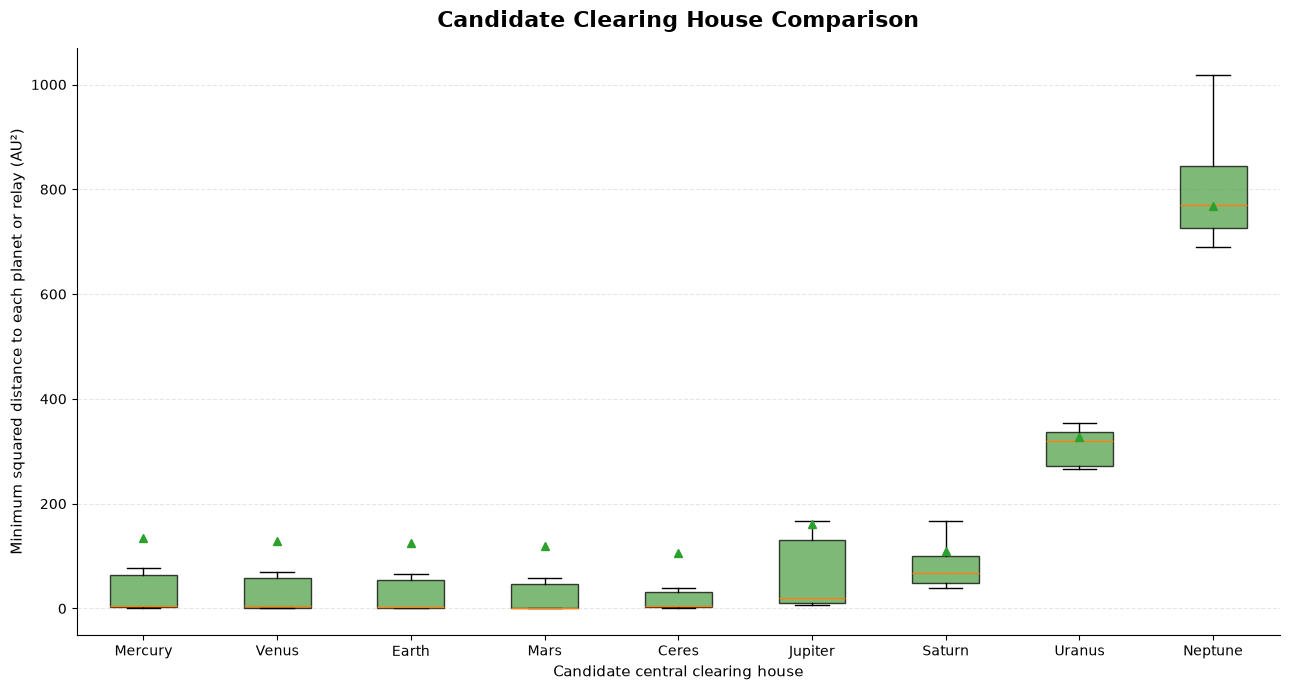

clearing_house target_node  minimum_squared_distance_au2
       Mercury       Venus                        0.0684
       Mercury       Earth                        0.3011
       Mercury        Mars                        0.9338
       Mercury       Ceres                        4.7282
       Mercury     Jupiter                       23.3415
       Mercury      Saturn                       76.3225
       Mercury      Uranus                      354.0912
       Mercury     Neptune                      869.9504
       Mercury     Relay A                        5.5891
       Mercury     Relay B                        5.5874
         Venus     Mercury                        0.0684
         Venus       Earth                        0.0702
         Venus        Mars                        0.5107
         Venus       Ceres                        3.3774
         Venus     Jupiter                       21.2342
         Venus      Saturn                       69.4327
         Venus      Uranus     

,clearing_house,target_node,minimum_squared_distance_au2
0,Mercury,Venus,0.068379
1,Mercury,Earth,0.301113
2,Mercury,Mars,0.933818
3,Mercury,Ceres,4.728208
4,Mercury,Jupiter,23.341473
...,...,...,...
85,Neptune,Jupiter,1019.037006
86,Neptune,Saturn,423.271480
87,Neptune,Uranus,689.151259
88,Neptune,Relay A,729.860023


In [14]:
node_names = list(SETTLEMENTS) + list(RELAYS)
all_node_positions = np.concatenate([planet_positions, relay_positions], axis=1)
clearing_house_box_data = []
clearing_house_rows = []

for clearing_house_index, clearing_house in enumerate(SETTLEMENTS):
    clearing_house_position = planet_positions[:, clearing_house_index, :]
    squared_distances = np.sum(
        (all_node_positions - clearing_house_position[:, np.newaxis, :]) ** 2,
        axis=-1,
    )
    squared_distances[:, clearing_house_index] = np.inf
    minimum_squared_distance = squared_distances.min(axis=0)
    minimum_squared_distance = np.delete(minimum_squared_distance, clearing_house_index)
    target_names = [
        name for index, name in enumerate(node_names)
        if index != clearing_house_index
    ]

    clearing_house_box_data.append(minimum_squared_distance)
    clearing_house_rows.extend(
        {
            "clearing_house": clearing_house,
            "target_node": target,
            "minimum_squared_distance_au2": distance,
        }
        for target, distance in zip(target_names, minimum_squared_distance)
    )

fig, ax = plt.subplots(figsize=(13, 7))
clearing_house_boxplot = ax.boxplot(
    clearing_house_box_data,
    tick_labels=SETTLEMENTS,
    patch_artist=True,
    showfliers=False,
    showmeans=True,
)
for patch in clearing_house_boxplot["boxes"]:
    patch.set_facecolor("#54A24B")
    patch.set_alpha(0.75)

ax.set_xlabel("Candidate central clearing house", fontsize=11)
ax.set_ylabel("Minimum squared distance to each planet or relay (AU²)", fontsize=11)
ax.set_title(
    "Candidate Clearing House Comparison",
    fontsize=16,
    weight="bold",
    pad=15,
)
ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

clearing_house_dataframe = pd.DataFrame(clearing_house_rows)
print(clearing_house_dataframe.to_string(index=False, float_format="{:.4f}".format))
clearing_house_dataframe

# Probability Matrix

In [30]:
from network_graph import BACKBONE_LOSS, DIRECT_LOSS

RELAY_ATTEMPTS = 2

planet_to_planet_distance = np.linalg.norm(
    planet_positions[:, :, np.newaxis, :] - planet_positions[:, np.newaxis, :, :],
    axis=-1,
)

# Direct service uses the direct-link loss coefficient.
direct_probability_matrix = np.exp(-DIRECT_LOSS * planet_to_planet_distance).mean(axis=0)

# Each relay route has two backbone hops: planet -> relay -> clearing house.
# Two retries succeed unless both route attempts fail: 1 - P(L)^2.
relay_probability_matrices = {}
for relay_index, relay_name in enumerate(RELAYS):
    source_to_relay = distance_by_relay[:, :, relay_index]
    relay_to_clearing_house = distance_by_relay[:, :, relay_index][:, np.newaxis, :]
    route_distance = source_to_relay[:, :, np.newaxis] + relay_to_clearing_house
    route_loss_probability = 1 - np.exp(-BACKBONE_LOSS * route_distance)
    route_probability = 1 - route_loss_probability ** RELAY_ATTEMPTS
    relay_probability_matrices[relay_name] = route_probability.mean(axis=0)

probability_matrices = {
    "direct": pd.DataFrame(
        direct_probability_matrix,
        index=SETTLEMENTS,
        columns=SETTLEMENTS,
    ),
    **{
        f"via {relay_name}": pd.DataFrame(
            matrix,
            index=SETTLEMENTS,
            columns=SETTLEMENTS,
        )
        for relay_name, matrix in relay_probability_matrices.items()
    },
}

route_names = list(probability_matrices)
route_arrays = np.stack([
    probability_matrices[route_name].to_numpy()
    for route_name in route_names
])
best_route_indices = route_arrays.argmax(axis=0)
probability_matrix = pd.DataFrame(
    route_arrays.max(axis=0),
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)
selected_route_matrix = pd.DataFrame(
    np.vectorize(route_names.__getitem__)(best_route_indices),
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)

for route_name, matrix in probability_matrices.items():
    print(f"\\nAverage route success probability: {route_name}")
    print(matrix.to_string(float_format="{:.4f}".format))

print("\\nHighest-probability route for each source and clearing-house pair:")
print(probability_matrix.to_string(float_format="{:.4f}".format))
selected_route_matrix

\nAverage route success probability: direct
         Mercury  Venus  Earth   Mars  Ceres  Jupiter  Saturn  Uranus  Neptune
Mercury   1.0000 0.9395 0.9203 0.8814 0.8005   0.6513  0.4753  0.2119   0.0915
Venus     0.9395 1.0000 0.9134 0.8792 0.8005   0.6486  0.4789  0.2142   0.0918
Earth     0.9203 0.9134 1.0000 0.8751 0.7993   0.6498  0.4778  0.2140   0.0916
Mars      0.8814 0.8792 0.8751 1.0000 0.7909   0.6572  0.4708  0.2143   0.0893
Ceres     0.8005 0.8005 0.7993 0.7909 1.0000   0.6410  0.4716  0.2128   0.0944
Jupiter   0.6513 0.6486 0.6498 0.6572 0.6410   1.0000  0.3238  0.1702   0.0641
Saturn    0.4753 0.4789 0.4778 0.4708 0.4716   0.3238  1.0000  0.3678   0.1605
Uranus    0.2119 0.2142 0.2140 0.2143 0.2128   0.1702  0.3678  1.0000   0.1087
Neptune   0.0915 0.0918 0.0916 0.0893 0.0944   0.0641  0.1605  0.1087   1.0000
\nAverage route success probability: via Relay A
         Mercury  Venus  Earth   Mars  Ceres  Jupiter  Saturn  Uranus  Neptune
Mercury   0.9884 0.9883 0.9880 0.9867 

,Mercury,Venus,Earth,Mars,Ceres,Jupiter,Saturn,Uranus,Neptune
Mercury,direct,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Venus,via Relay B,direct,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Earth,via Relay B,via Relay B,direct,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Mars,via Relay B,via Relay B,via Relay B,direct,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Ceres,via Relay B,via Relay B,via Relay B,via Relay B,direct,via Relay A,via Relay B,via Relay B,via Relay B
Jupiter,via Relay A,via Relay A,via Relay A,via Relay A,via Relay A,direct,via Relay A,via Relay A,via Relay A
Saturn,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,direct,via Relay B,via Relay B
Uranus,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,direct,via Relay B
Neptune,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,direct


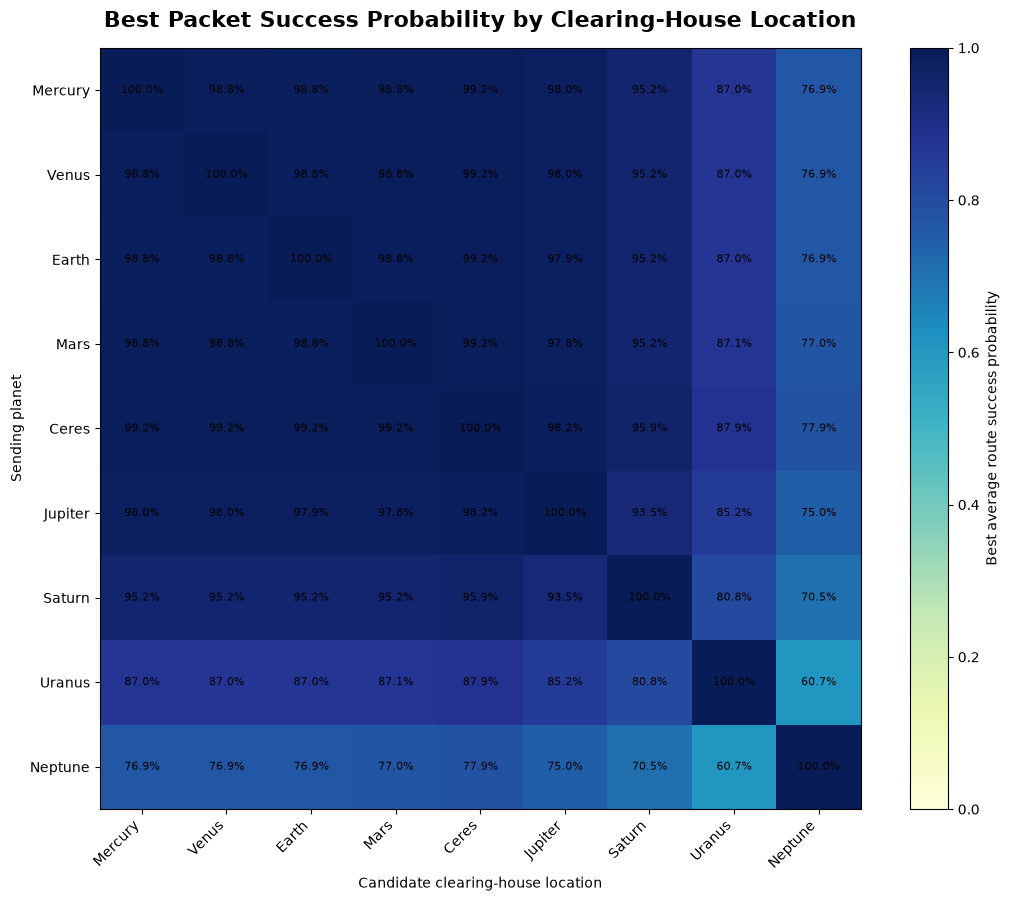

Best route for each source and clearing-house pair:


,Mercury,Venus,Earth,Mars,Ceres,Jupiter,Saturn,Uranus,Neptune
Mercury,direct,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Venus,via Relay B,direct,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Earth,via Relay B,via Relay B,direct,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Mars,via Relay B,via Relay B,via Relay B,direct,via Relay B,via Relay A,via Relay B,via Relay B,via Relay B
Ceres,via Relay B,via Relay B,via Relay B,via Relay B,direct,via Relay A,via Relay B,via Relay B,via Relay B
Jupiter,via Relay A,via Relay A,via Relay A,via Relay A,via Relay A,direct,via Relay A,via Relay A,via Relay A
Saturn,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,direct,via Relay B,via Relay B
Uranus,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,direct,via Relay B
Neptune,via Relay B,via Relay B,via Relay B,via Relay B,via Relay B,via Relay A,via Relay B,via Relay B,direct


In [31]:
route_names = list(probability_matrices)
route_arrays = np.stack([
    probability_matrices[route_name].to_numpy()
    for route_name in route_names
])
best_route_indices = route_arrays.argmax(axis=0)
best_probability_matrix = route_arrays.max(axis=0)
best_route_matrix = np.vectorize(route_names.__getitem__)(best_route_indices)

best_probability_dataframe = pd.DataFrame(
    best_probability_matrix,
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)
best_route_dataframe = pd.DataFrame(
    best_route_matrix,
    index=SETTLEMENTS,
    columns=SETTLEMENTS,
)

fig, ax = plt.subplots(figsize=(11, 9))
heatmap = ax.imshow(
    best_probability_matrix,
    cmap="YlGnBu",
    vmin=0.0,
    vmax=1.0,
    aspect="equal",
)
fig.colorbar(heatmap, ax=ax, label="Best average route success probability")

ax.set_xticks(np.arange(len(SETTLEMENTS)))
ax.set_yticks(np.arange(len(SETTLEMENTS)))
ax.set_xticklabels(SETTLEMENTS, rotation=45, ha="right")
ax.set_yticklabels(SETTLEMENTS)
ax.set_xlabel("Candidate clearing-house location")
ax.set_ylabel("Sending planet")
ax.set_title(
    "Best Packet Success Probability by Clearing-House Location",
    fontsize=16,
    weight="bold",
    pad=15,
)

for source_index in range(len(SETTLEMENTS)):
    for clearing_house_index in range(len(SETTLEMENTS)):
        probability = best_probability_matrix[source_index, clearing_house_index]
        ax.text(
            clearing_house_index,
            source_index,
            f"{probability:.1%}",
            ha="center",
            va="center",
            color="white" if probability < 0.55 else "black",
            fontsize=8,
        )

plt.tight_layout()
plt.show()

print("Best route for each source and clearing-house pair:")
best_route_dataframe

In [33]:
def rank_clearing_houses(probability_matrix):
    """Rank candidates using equally weighted average squared success probability."""
    scores = []
    for candidate in probability_matrix.columns:
        source_probabilities = probability_matrix[candidate].drop(index=candidate)
        limiting_source = source_probabilities.idxmin()
        scores.append({
            "clearing_house": candidate,
            "average_squared_success_probability": np.mean(source_probabilities.to_numpy() ** 2),
            "average_success_probability": source_probabilities.mean(),
            "worst_case_success_probability": source_probabilities.min(),
            "limiting_source": limiting_source,
            "best_case_success_probability": source_probabilities.max(),
        })

    return (
        pd.DataFrame(scores)
        .sort_values(
            ["average_squared_success_probability", "worst_case_success_probability"],
            ascending=False,
        )
        .reset_index(drop=True)
    )

clearing_house_ranking = rank_clearing_houses(probability_matrix)
clearing_house_ranking

,clearing_house,average_squared_success_probability,average_success_probability,worst_case_success_probability,limiting_source,best_case_success_probability
0,Ceres,0.899560,0.945665,0.778928,Neptune,0.991880
1,Mercury,0.891233,0.941041,0.769344,Neptune,0.991809
2,Venus,0.891064,0.940950,0.769263,Neptune,0.991743
3,Mars,0.891015,0.940957,0.770109,Neptune,0.991880
4,Earth,0.890837,0.940830,0.769146,Neptune,0.991647
5,Jupiter,0.870067,0.929356,0.749666,Neptune,0.981771
6,Saturn,0.821078,0.901833,0.704694,Neptune,0.958563
7,Uranus,0.693613,0.828355,0.607113,Neptune,0.878983
8,Neptune,0.550277,0.739783,0.607113,Uranus,0.778928
